In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

import sys

LMMGEN_PATH = "/home/inigog/LMMGen"

sys.path.append(f"{LMMGEN_PATH}/kokoro")
from tts_utils import estimate_audio_duration
from tts_utils import get_sentences
from tts_utils import split_into_sentences_max_duration
from tts_utils import get_audio_chunks_by_silences
from tts_utils import detect_silences

sys.path.append(LMMGEN_PATH)
from media_utils import chunk_audio_base64
from file_utils import read_file_base64
from media_utils import get_audio_duration

In [2]:
MAX_DURATION_SECONDS = 5

# Text split

In [3]:
PODCAST_JSON_PATH = f"{LMMGEN_PATH}/kokoro/data/sample_podcast.json"
with open(PODCAST_JSON_PATH, "r") as f:
    data = json.load(f)

In [4]:
for scene in data["scenes"]:
    for dialogue in scene["dialogues"]:
        sentence = dialogue["transcript"]
        duration = estimate_audio_duration(sentence)
        print(f"Original: {sentence} ({duration:.2f} seconds)")

        # Basic sub-sentences extraction
        print("  Basic split:")
        sub_sentences = get_sentences(sentence)
        for sub_sentence in sub_sentences:
            duration = estimate_audio_duration(sub_sentence)
            print(f"    {sub_sentence} ({duration:.2f} seconds)")
        
        # Splitting into sentences with max duration
        print("  Greedy split:")
        sub_sentences = split_into_sentences_max_duration(sentence, MAX_DURATION_SECONDS)
        if sub_sentences:
            for sub_sentence in sub_sentences:
                duration = estimate_audio_duration(sub_sentence)
                print(f"    {sub_sentence} ({duration:.2f} seconds)")

Original: Hello and welcome to 'Decoding the Abstract'! Today, we're tackling... well, a bit of a mystery. We received a document – a PDF, to be exact – and the task is to decipher its main theme. Now, this isn't your typical research paper, folks. It's... blank. Completely blank. (19.20 seconds)
  Basic split:
    Hello and welcome to 'Decoding the Abstract'! (2.93 seconds)
    Today, we're tackling... (1.56 seconds)
    well, a bit of a mystery. (2.40 seconds)
    We received a document – a PDF, to be exact – and the task is to decipher its main theme. (8.00 seconds)
    Now, this isn't your typical research paper, folks. (3.31 seconds)
    It's... (0.46 seconds)
    blank. (0.40 seconds)
    Completely blank. (1.10 seconds)
  Greedy split:
    Hello and welcome to 'Decoding the Abstract'! Today, we're tackling... (4.55 seconds)
    We received a document – a PDF, to be exact – (4.40 seconds)
    and the task is to decipher its main theme. (3.60 seconds)
    Now, this isn't your typi

# Duration estimation

In [5]:
CSV_PATH = f"{LMMGEN_PATH}/kokoro/data/audio_duration.csv"
df_data = pd.read_csv(CSV_PATH)

In [6]:
df_data

,characters,words,sentences,bytes,seconds
0,0,0,-1,0,0.00
1,23,4,-1,124860,1.95
2,23,4,-1,124860,1.95
3,42,6,-1,188860,2.95
4,42,6,-1,188860,2.95
...,...,...,...,...,...
87,276,41,4,1104060,17.25
88,499,76,4,1872060,29.25
89,460,67,5,1796860,28.08
90,50,10,2,208060,3.25


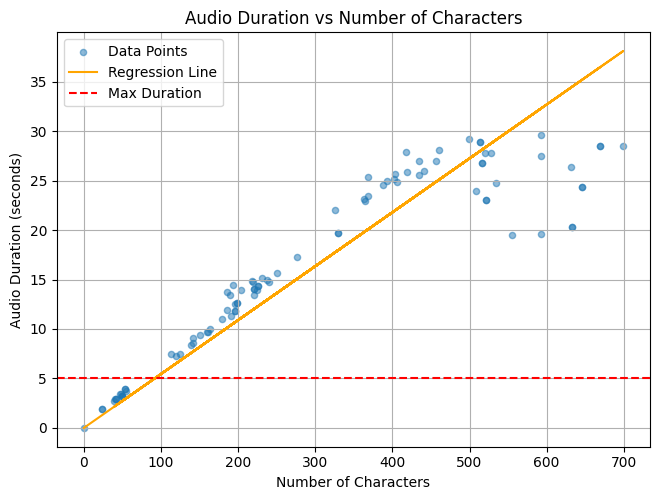

In [7]:
df_data.plot(
    x="characters",
    y="seconds",
    kind="scatter",
    title="Audio Duration vs Number of Characters",
    xlabel="Number of Characters",
    ylabel="Audio Duration (seconds)",
    grid=True,
    label='Data Points',
    alpha=0.5,
)

regression_line = df_data["seconds"].mean() * (df_data["characters"] / df_data["characters"].mean())
plt.plot(df_data["characters"], regression_line, color='orange', label='Regression Line')

plt.axhline(y=MAX_DURATION_SECONDS, color='r', linestyle='--', label='Max Duration')

plt.legend()
plt.tight_layout(pad=0)
plt.show()

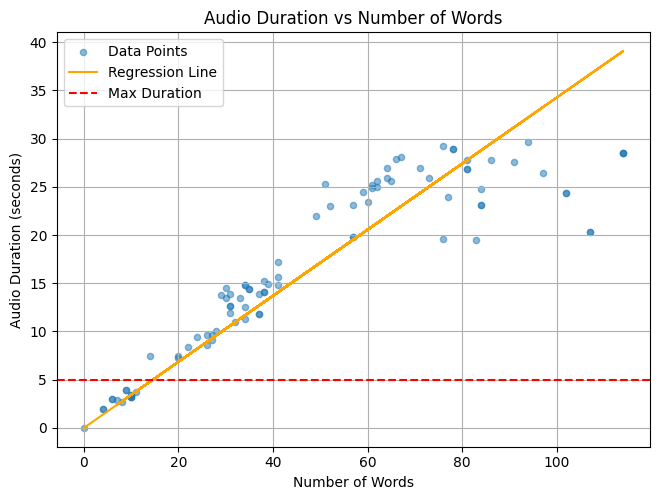

In [8]:
df_data.plot(
    x="words",
    y="seconds",
    kind="scatter",
    title="Audio Duration vs Number of Words",
    xlabel="Number of Words",
    ylabel="Audio Duration (seconds)",
    grid=True,
    label='Data Points',
    alpha=0.5
)

regression_line = df_data["seconds"].mean() * (df_data["words"] / df_data["words"].mean())
plt.plot(df_data["words"], regression_line, color='orange', label='Regression Line')

plt.axhline(y=MAX_DURATION_SECONDS, color='r', linestyle='--', label='Max Duration')

plt.legend()
plt.tight_layout(pad=0)
plt.show()

# Split audio

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

WAV_PATH = f"{LMMGEN_PATH}/kokoro/data/longsample.wav"
WAV_PATH = f"{LMMGEN_PATH}/kokoro/data/mediumsample.wav"

In [10]:
rate, data = wavfile.read(WAV_PATH)
if data.ndim > 1:
    data = data.mean(axis=1).astype(data.dtype)

In [11]:
silences = {}
for silence_duration_ms in [200, 100, 50, 10]:
    THRESHOLD = 500
    silences[silence_duration_ms] = detect_silences(
        data, rate,
        min_silence_duration_seconds=silence_duration_ms / 1000.0)
print(silences)

{200: [(0.0, 0.32325), (2.7550416666666666, 3.184375), (4.905375, 5.375)], 100: [(0.0, 0.32325), (0.8139166666666666, 0.9494583333333333), (2.7550416666666666, 3.184375), (4.905375, 5.375)], 50: [(0.0, 0.32325), (0.4982916666666667, 0.566), (0.8139166666666666, 0.9494583333333333), (1.9157083333333333, 1.9659166666666668), (2.1093333333333333, 2.162333333333333), (2.4636666666666667, 2.5249166666666665), (2.7550416666666666, 3.184375), (3.7592083333333335, 3.829375), (4.905375, 5.375)], 10: [(0.0, 0.32325), (0.4982916666666667, 0.566), (0.8139166666666666, 0.9494583333333333), (1.5257083333333334, 1.5633333333333332), (1.9157083333333333, 1.9659166666666668), (2.1093333333333333, 2.162333333333333), (2.2464583333333334, 2.286875), (2.4636666666666667, 2.5249166666666665), (2.7550416666666666, 3.184375), (3.1844166666666665, 3.212833333333333), (3.3308333333333335, 3.3802916666666665), (3.5565416666666665, 3.583875), (3.7592083333333335, 3.829375), (4.573916666666666, 4.603041666666667)

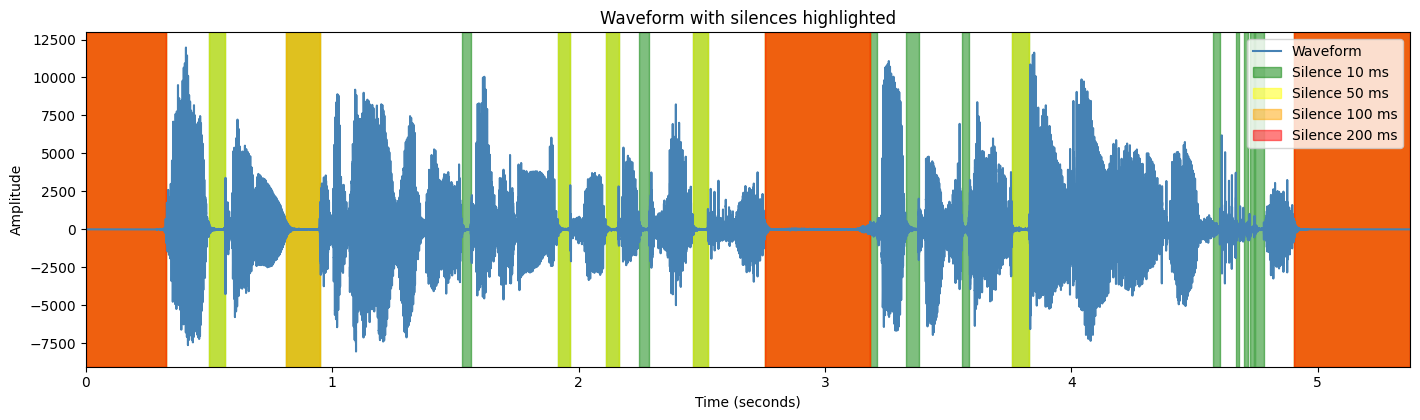

In [12]:
plt.figure(figsize=(14, 4))
times = np.arange(len(data)) / rate
plt.plot(times, data, label="Waveform", color="steelblue")

color_map = {
    200: "red",
    100: "orange",
    50: "yellow",
    10: "green"
}
for silence_duration, start_end in reversed(silences.items()):
    for silence_start, silence_end in start_end:
        plt.axvspan(
            silence_start, silence_end,
            color=color_map[silence_duration],
            alpha=0.5,
            label=f"Silence {silence_duration} ms" if silence_start == start_end[0][0] else None)

plt.xlim(0, len(data) / rate)
plt.title("Waveform with silences highlighted")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout(pad=0)
plt.show()

In [13]:
audio_splits = get_audio_chunks_by_silences(WAV_PATH, MAX_DURATION_SECONDS)

In [14]:
print(audio_splits)

[(0.0, 2.969708333333333), (2.969708333333333, 5.375)]


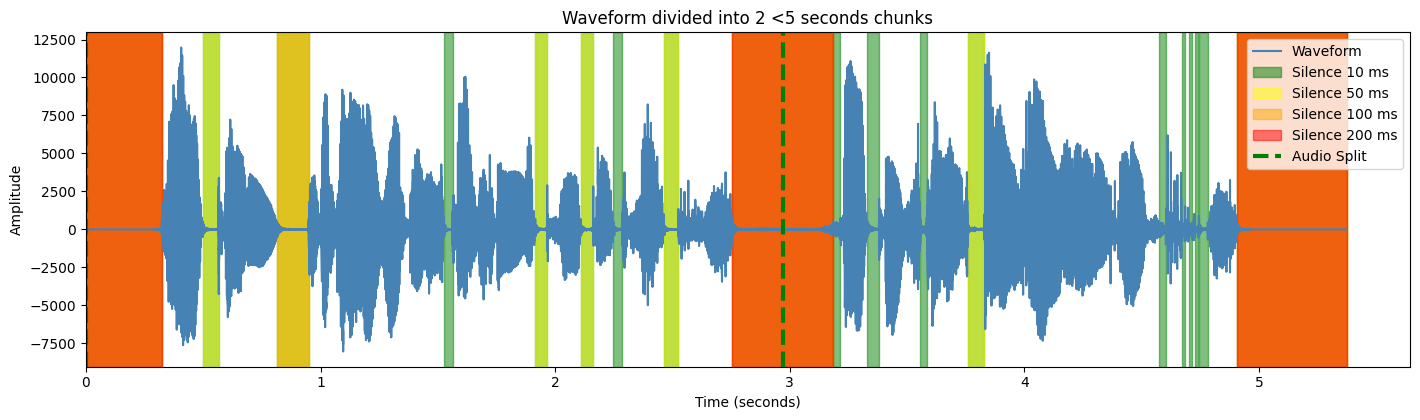

In [15]:
plt.figure(figsize=(14, 4))
times = np.arange(len(data)) / rate
plt.plot(times, data, label="Waveform", color="steelblue")

color_map = {
    200: "red",
    100: "orange",
    50: "yellow",
    10: "green"
}
for silence_duration, start_end in reversed(silences.items()):
    for silence_start, silence_end in start_end:
        plt.axvspan(
            silence_start, silence_end,
            color=color_map[silence_duration],
            alpha=0.5,
            label=f"Silence {silence_duration} ms" if silence_start == start_end[0][0] else None)

# Plot audio_splits as vertical lines
for ix, (start_seconds, end_seconds) in enumerate(audio_splits):
    plt.axvline(
        x=start_seconds,
        color="green",
        lw=3,
        linestyle='--',
        label='Audio Split' if ix == 0 else None)

plt.title(f"Waveform divided into {len(audio_splits)} <{MAX_DURATION_SECONDS} seconds chunks")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.xlim(0, None)
plt.tight_layout(pad=0.0)
plt.show()

In [ ]:
start_seconds = 0.0
audio_base64 = await read_file_base64(WAV_PATH)
for start_seconds, end_seconds in audio_splits:
    chunk_audio = chunk_audio_base64(audio_base64, start_seconds, end_seconds)
    duration_seconds = get_audio_duration(chunk_audio)
    print(f"{start_seconds:7.3f} {end_seconds:7.3f} -> {duration_seconds:7.3f}")
    start_seconds = end_seconds

  0.000   2.970 ->   2.970
  2.970   5.375 ->   2.405
